In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import math
from collections import Counter

pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings("ignore")

# Data downloading

### Download the data from Kaggle (for Colab)

In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

# import os

# !mkdir -p ~/.kaggle
# !cp "/content/drive/MyDrive/Colab Notebooks/kaggle.json" ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json

# !kaggle competitions download -c home-credit-default-risk --force

In [3]:
# import zipfile

# zip_path = "/content/home-credit-default-risk.zip"
# extract_dir = "/content/home-credit-data"

# # Создаём папку для распаковки
# os.makedirs(extract_dir, exist_ok=True)

# # Распаковка
# with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#     zip_ref.extractall(extract_dir)

# # Проверим, что распаковано
# os.listdir(extract_dir)

In [ ]:
# For Colab
# app_train = pd.read_csv(f'{extract_dir}/application_train.csv')
# app_test = pd.read_csv(f'{extract_dir}/application_test.csv')

In [4]:
app_train = pd.read_csv('Data/application_train.csv')
app_test = pd.read_csv('Data/application_test.csv')

In [5]:
print ("Формат обучающей выборки:", app_train.shape)
print ("Формат тестовой выборки:", app_test.shape)

Формат обучающей выборки: (307511, 122)
Формат тестовой выборки: (48744, 121)


# EDA

## Counting NaNs:

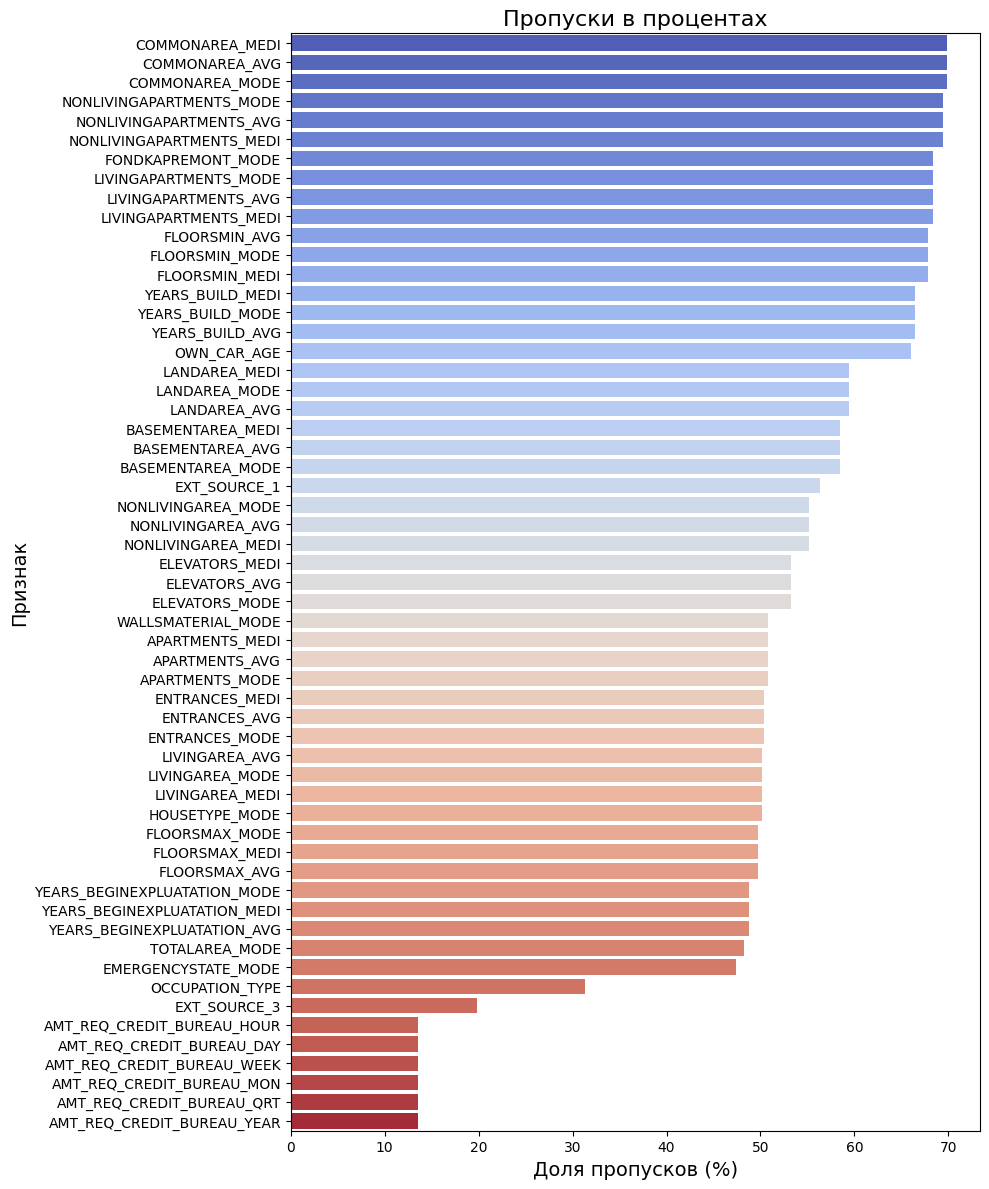

In [6]:
missing_pct = (app_train.isnull().sum() / len(app_train) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 1]

plt.figure(figsize=(10, 12))
sns.barplot(x=missing_pct.values, y=missing_pct.index, palette='coolwarm', hue=None)
plt.title("Пропуски в процентах", fontsize=16)
plt.xlabel("Доля пропусков (%)", fontsize=14)
plt.ylabel("Признак", fontsize=14)
plt.tight_layout()
plt.show()

Можно заметить, что довольно большая часть датасета имеет пропуски (до 70%). В разделе Feature Engineering будем искать решение этой проблемы

## Check for the outliers

In [7]:
def plot_boxplots(features_list, df):
    n = len(features_list)
    cols = 3
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
    axes = axes.flatten()

    for i, feature in enumerate(features_list):
        Q1 = df[feature].quantile(0.25)
        Q3 = df[feature].quantile(0.75)
        IQR = Q3 - Q1

        lower_whisker = Q1 - 1.5 * IQR
        upper_whisker = Q3 + 1.5 * IQR

        outliers = app_train[
            (df[feature] < lower_whisker) |
            (df[feature] > upper_whisker)
        ]

        sns.boxplot(x=df[feature], ax=axes[i], label=f'Количество выбросов: {outliers.shape[0]}\nДоля выбросов: {outliers.shape[0] / app_train.shape[0]:.2%}')
        axes[i].set_title(feature)

    plt.tight_layout()
    plt.show()


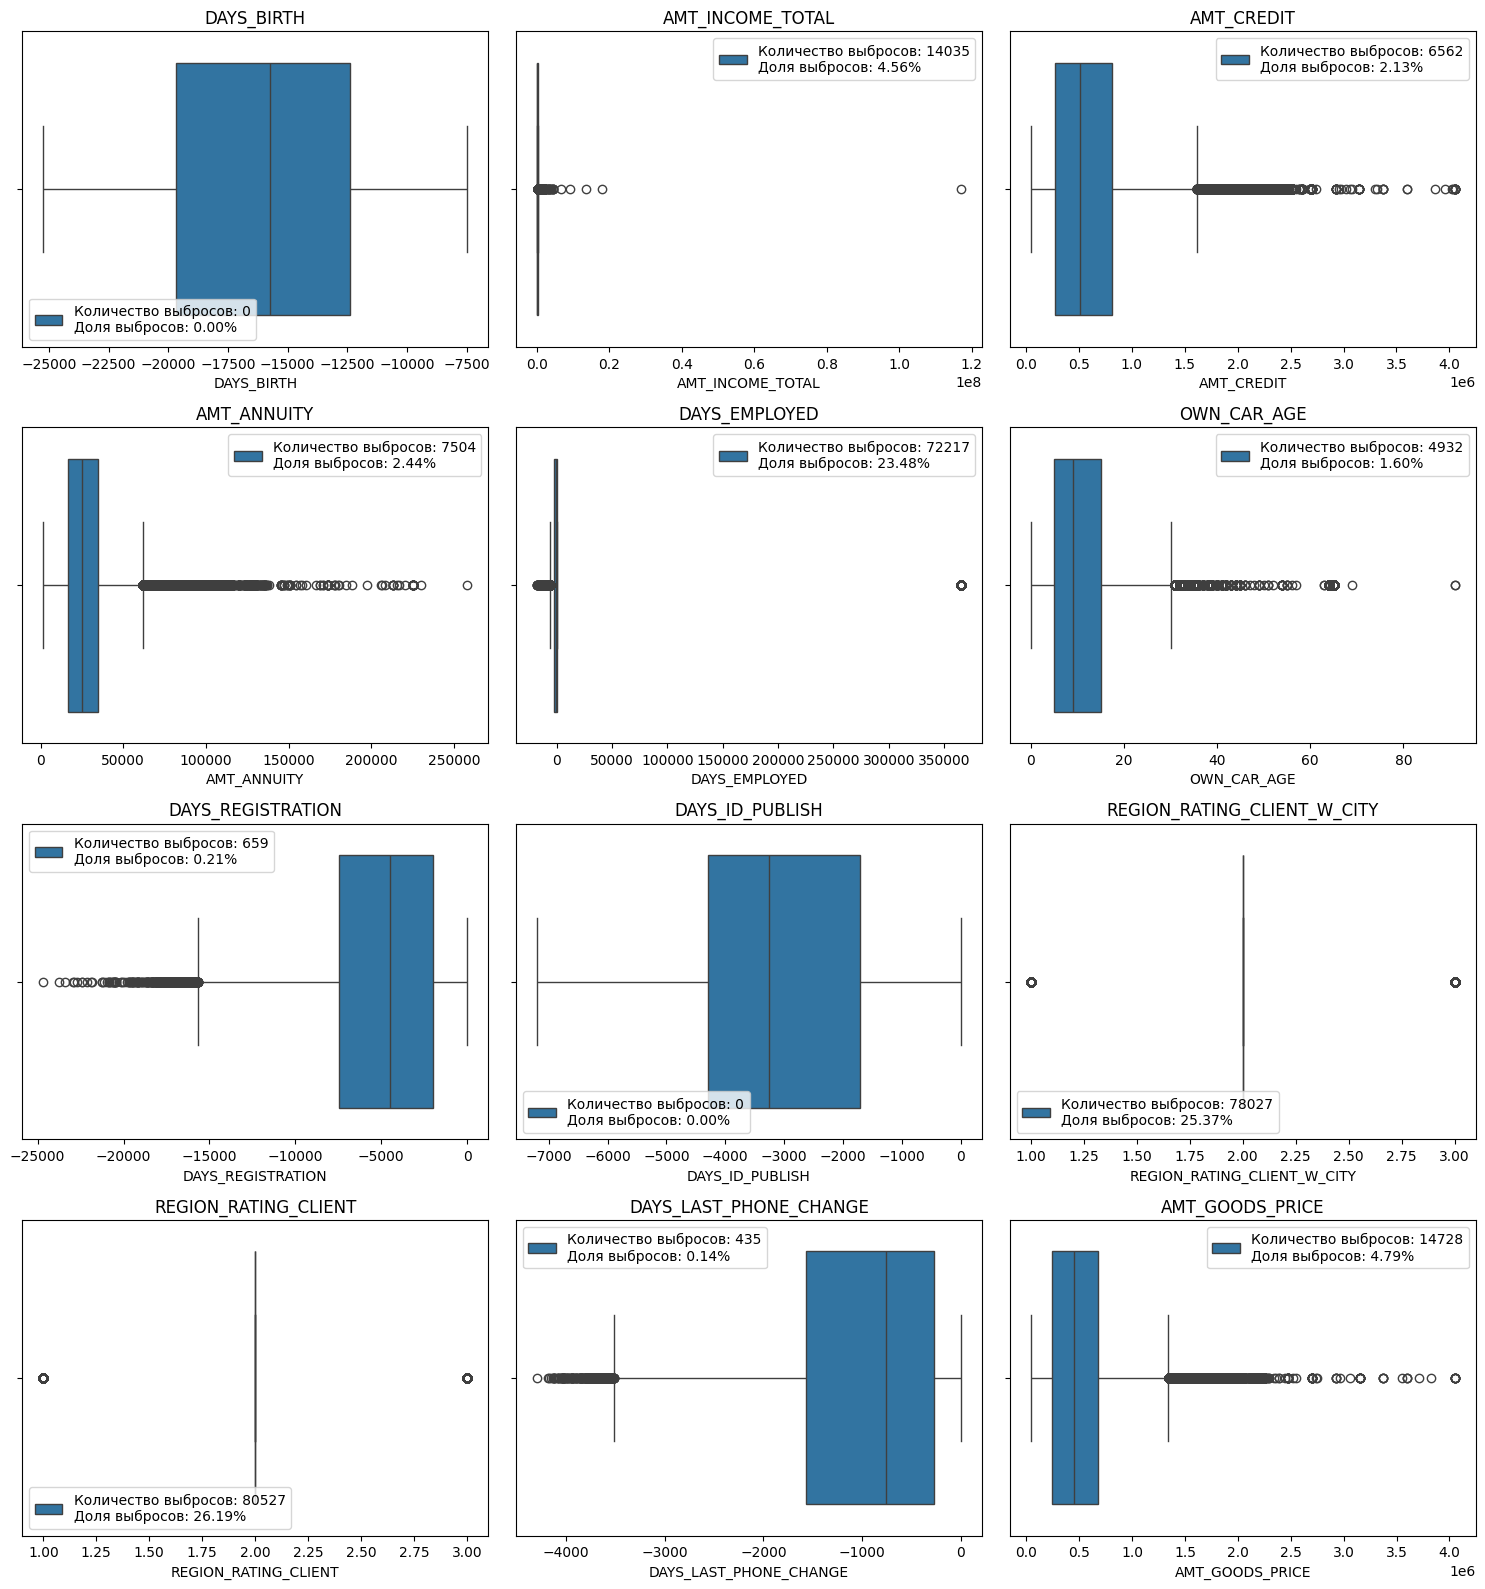

In [8]:
plot_boxplots(
    [
        'DAYS_BIRTH',
        'AMT_INCOME_TOTAL',
        'AMT_CREDIT',
        'AMT_ANNUITY',
        'DAYS_EMPLOYED',
        'OWN_CAR_AGE',
        'DAYS_REGISTRATION',
        'DAYS_ID_PUBLISH',
        'REGION_RATING_CLIENT_W_CITY',
        'REGION_RATING_CLIENT',
        'DAYS_LAST_PHONE_CHANGE',
        'AMT_GOODS_PRICE'
    ],
    app_train
)

Исходя из данных графиков, можно точно сказать, что выбросами являются:

1) AMT INCOME_TOTAL - Ежегодный доход в 120 млн. рублей

2) DAYS_EMPLOYED - Опыт работы на текущем месте работы около 350 тыс. дней

Остальные значения хоть и выбиваются за пределы "усов", но имеют реальное обоснование и их удаление будет неправильным.

## Target distribution

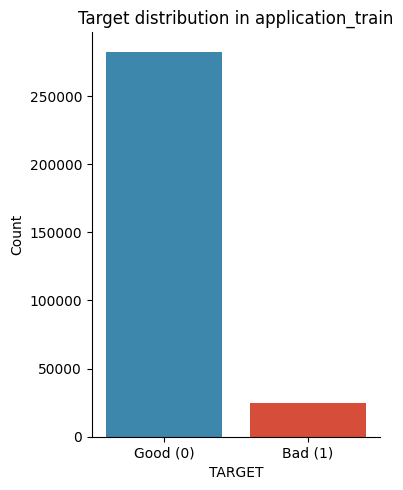

In [9]:
counts = app_train['TARGET'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(4,5))
sns.barplot(x=counts.index, y=counts.values, ax=ax, palette=['#2b8cbe','#f03b20'])

ax.set_xticklabels(['Good (0)','Bad (1)'])
ax.set_ylabel('Count')
ax.set_title('Target distribution in application_train')

sns.despine(left=False)
plt.tight_layout()
plt.show()

Можно увидеть явный дисбаланс классов, что будет сильно мешать нашей модели правильно обучаться.

## Coefficients of correlation

Воспользуемся коэффициентами корреляции Пирсона, хоть это и не лучший метод для подбора фичей, однако, он прост и позволяет составить первоначальное представление о данных.

In [10]:
# Select only numeric columns before calculating correlations
correlations = app_train.select_dtypes(include=np.number).corr()['TARGET'].sort_values()

print('Наивысшая позитивная корреляция:\n', correlations.tail(15))
print('\nНаивысшая негативная коррелация:\n', correlations.head(15))

Наивысшая позитивная корреляция:
 DEF_60_CNT_SOCIAL_CIRCLE       0.031276
DEF_30_CNT_SOCIAL_CIRCLE       0.032248
LIVE_CITY_NOT_WORK_CITY        0.032518
OWN_CAR_AGE                    0.037612
DAYS_REGISTRATION              0.041975
FLAG_DOCUMENT_3                0.044346
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_EMP_PHONE                 0.045982
REG_CITY_NOT_WORK_CITY         0.050994
DAYS_ID_PUBLISH                0.051457
DAYS_LAST_PHONE_CHANGE         0.055218
REGION_RATING_CLIENT           0.058899
REGION_RATING_CLIENT_W_CITY    0.060893
DAYS_BIRTH                     0.078239
TARGET                         1.000000
Name: TARGET, dtype: float64

Наивысшая негативная коррелация:
 EXT_SOURCE_3                 -0.178919
EXT_SOURCE_2                 -0.160472
EXT_SOURCE_1                 -0.155317
DAYS_EMPLOYED                -0.044932
FLOORSMAX_AVG                -0.044003
FLOORSMAX_MEDI               -0.043768
FLOORSMAX_MODE               -0.043226
AMT_GOODS_PRICE              

Таким образом, все данные слабо коррелируют с таргетом. Однако выделяются возраст и некие "внешние источники данных", рассмотрим их подробнее.

### Возраст

In [11]:
app_train.DAYS_BIRTH.head(3)

0    -9461
1   -16765
2   -19046
Name: DAYS_BIRTH, dtype: int64

Сделаем возраст положительным и переведем в года для удобства:

In [12]:
app_train['AGE_YEARS'] = abs(app_train['DAYS_BIRTH']) / 365
app_test['AGE_YEARS'] = abs(app_test['DAYS_BIRTH']) / 365

app_train.drop('DAYS_BIRTH', axis=1, inplace=True)
app_test.drop('DAYS_BIRTH', axis=1, inplace=True)

Text(0, 0.5, 'Count')

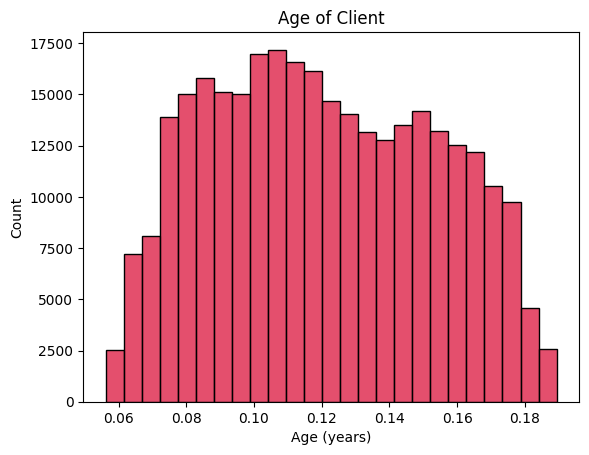

In [13]:
# Гистограмма распределения возраста в годах, всего 25 столбцов
sns.histplot(app_train['AGE_YEARS'] / 365, bins=25, color='crimson')
plt.title('Age of Client'); plt.xlabel('Age (years)'); plt.ylabel('Count')

Видно, что нет явных выбросов, распределение возраста довольно обычное.
Но нам нужно увидеть, как возраст людей влияет на плотность вероятности возникновения проблем людей с выплатами. Для этого воспользуемся quantile cut (pd.qcut)

qcut сортирует возраст, берет квантильные значения (25%, 50%, 75%), выравнивает количество наблюдений


                  Defaults  Total  Default_Rate
AGE_GROUP                                      
(20.517, 29.868]      5036  43947        0.1146
(29.868, 35.441]      4488  43929        0.1022
(35.441, 40.515]      3894  43919        0.0887
(40.515, 45.97]       3414  43945        0.0777
(45.97, 52.405]       3157  43926        0.0719
(52.405, 58.74]       2620  43920        0.0597
(58.74, 69.121]       2216  43925        0.0504


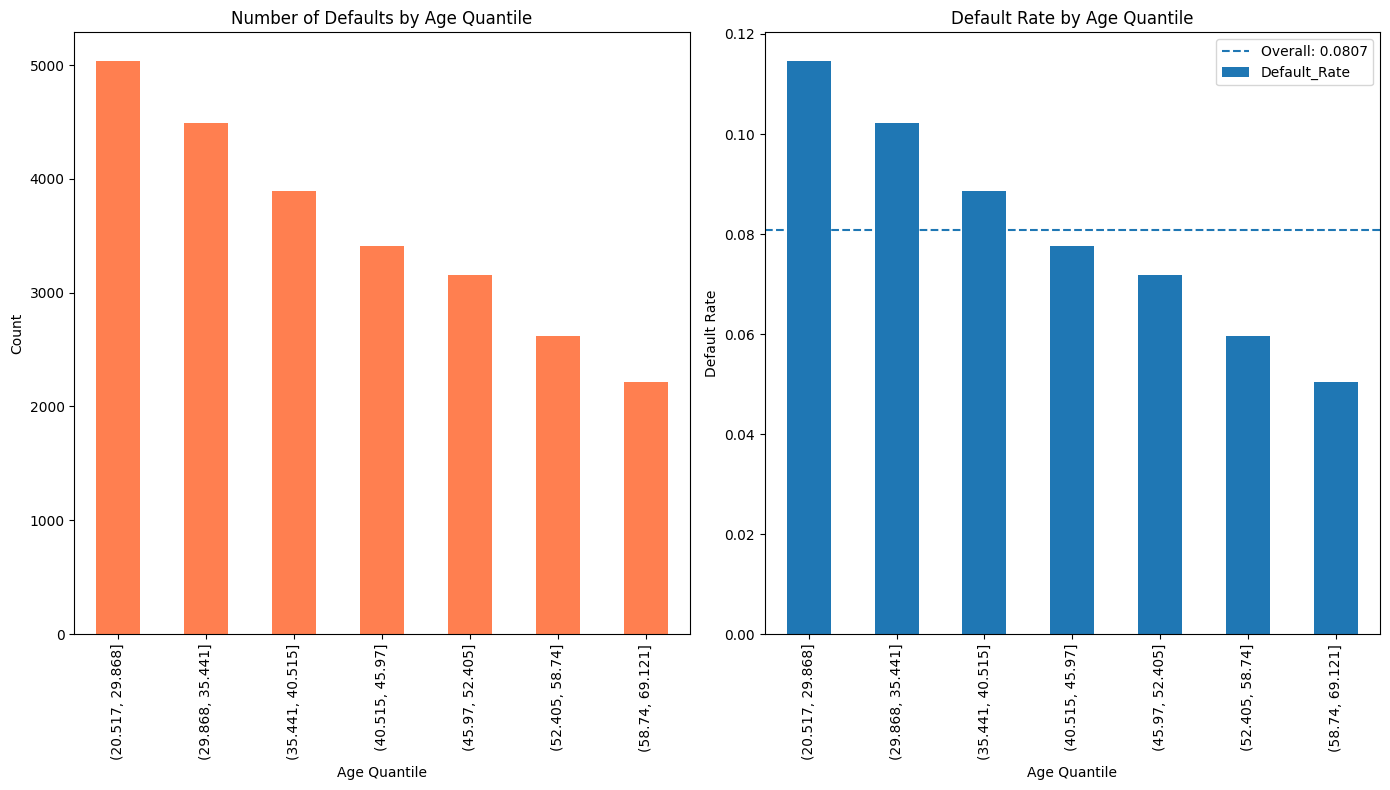

In [29]:
import seaborn as sns
from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt

# Работаем только с нужными колонками и без NaN
df = app_train[['AGE_YEARS', 'TARGET']].dropna()

# Автоматический биннинг по квантилям
df['AGE_GROUP'] = pd.qcut(
    df['AGE_YEARS'],
    q=7,
    duplicates='drop'
)

# Расчёт метрик по возрастным группам
default_by_age = (
    df
    .groupby('AGE_GROUP', observed=True)
    .agg(
        Defaults=('TARGET', 'sum'),
        Total=('TARGET', 'count'),
        Default_Rate=('TARGET', 'mean')
    )
    .round(4)
)

print(default_by_age)

# ===== Визуализация =====
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# График 1: количество дефолтов
default_by_age['Defaults'].plot(
    kind='bar',
    ax=axes[0],
    color='coral'
)
axes[0].set_title('Number of Defaults by Age Quantile')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Age Quantile')

# График 2: доля дефолтов
default_by_age['Default_Rate'].plot(
    kind='bar',
    ax=axes[1]
)
axes[1].set_title('Default Rate by Age Quantile')
axes[1].set_ylabel('Default Rate')
axes[1].set_xlabel('Age Quantile')

# Средний уровень дефолта по всей выборке
axes[1].axhline(
    y=df['TARGET'].mean(),
    linestyle='--',
    label=f'Overall: {df["TARGET"].mean():.4f}'
)
axes[1].legend()

plt.tight_layout()
plt.show()

Как видно, доля невозвратов выше для молодых людей и снижается с ростом возраста. Это не повод отказывать молодым людям в кредите полностью, такая "рекомендация" приведет лишь к потере доходов и довольно значимой части рынка для банка. Это повод задуматься о более тщательном их ведении, оценке и контроле.

### Внешние источники

Посмотрим внимательнее на "внешние источники данных" и их корреляцию.

In [30]:
ext_data = app_train[['TARGET', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'AGE_YEARS']]
ext_data_corrs = ext_data.corr()
ext_data_corrs

,TARGET,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,AGE_YEARS
TARGET,1.000000,-0.155317,-0.160472,-0.178919,-0.078239
EXT_SOURCE_1,-0.155317,1.000000,0.213982,0.186846,0.600610
EXT_SOURCE_2,-0.160472,0.213982,1.000000,0.109167,0.091996
EXT_SOURCE_3,-0.178919,0.186846,0.109167,1.000000,0.205478
AGE_YEARS,-0.078239,0.600610,0.091996,0.205478,1.000000


Удобнее будет отобразить корреляцию в heatmap

Text(0.5, 1.0, 'Correlation Heatmap')

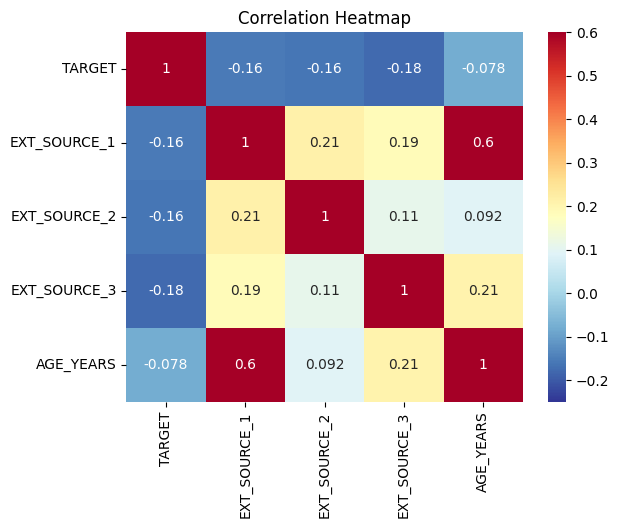

In [31]:
sns.heatmap(ext_data_corrs, cmap = plt.cm.RdYlBu_r, vmin = -0.25, annot = True, vmax = 0.6)
plt.title('Correlation Heatmap')

Как видно, все источники показывают негативную корреляцию с таргетом. Посмотрим на распределение KDE по каждому источнику.

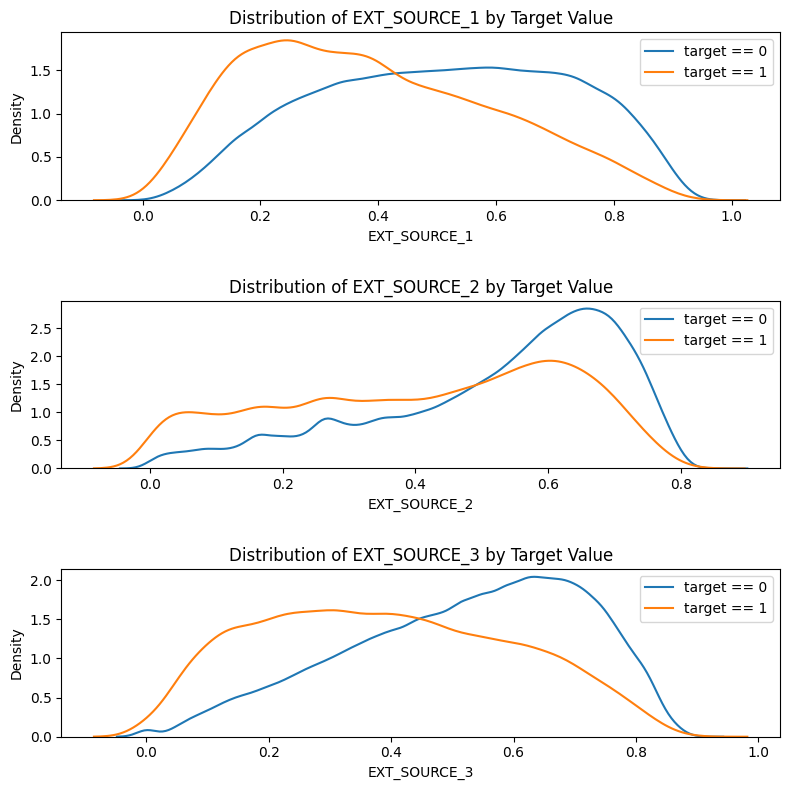

In [32]:
plt.figure(figsize = (8, 8))

# итерация по источникам
for i, feat_name in enumerate(['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']):

    # сабплот
    plt.subplot(3, 1, i + 1)
    # отрисовка качественных займов
    sns.kdeplot(app_train.loc[app_train['TARGET'] == 0, feat_name], label = 'target == 0')
    # отрисовка дефолтных займов
    sns.kdeplot(app_train.loc[app_train['TARGET'] == 1, feat_name], label = 'target == 1')

    # метки
    plt.legend()
    plt.title(f'Distribution of {feat_name} by Target Value')
    plt.xlabel(f'{feat_name}')
    plt.ylabel('Density')

plt.tight_layout(h_pad = 2.5)

## Other features exploration

Рассмотрим более подробно другие признаки и их зависимость от целевой переменной. Так как среди них много категориальных (а мы уже успели их закодировать), нам снова понадобятся исходные данные. Назовем DF немного по-другому во избежание путаницы.

In [34]:
application_train = pd.read_csv('Data/application_train.csv')
application_test = pd.read_csv('Data/application_test.csv')

In [35]:
def plot_stats(feature, label_rotation=0):
    sns.set_color_codes("pastel")

    feat_counts = application_train[feature].value_counts()
    count_df = pd.DataFrame({feature: feat_counts.index,'Loan count': feat_counts.values})

    # Counting target == 1 cats
    perc_df = application_train[[feature, 'TARGET']].groupby([feature], as_index=False).mean()
    perc_df.sort_values(by='TARGET', ascending=False, inplace=True)

    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,6))

    s = sns.barplot(ax=ax1, x = feature, y="Loan count", data=count_df, palette='Set2')
    s.set_xticklabels(s.get_xticklabels(), rotation=label_rotation)

    s = sns.barplot(ax=ax2, x = feature, y='TARGET', order=perc_df[feature], data=perc_df, palette='Set2')
    s.set_xticklabels(s.get_xticklabels(), rotation=label_rotation)

    plt.ylabel('Default Rate', fontsize=10)
    plt.tick_params(axis='both', which='major', labelsize=10)
    plt.show()

### Contract type

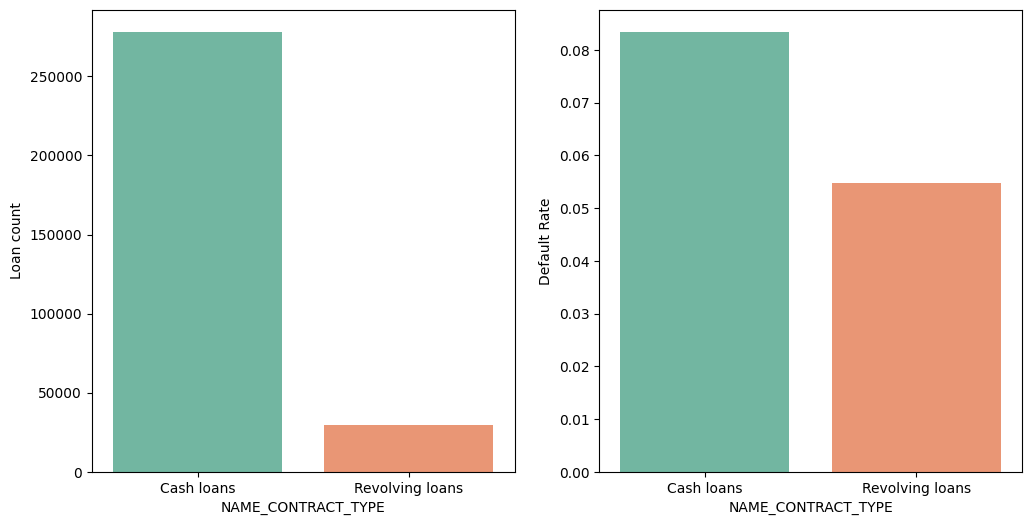

In [36]:
plot_stats('NAME_CONTRACT_TYPE')

Интересно, что револьверные кредиты (вероятно, овердрафты или что-то вроде того) составляют меньше 10% от общего количества займов. В то же время процент невозврата сравнительно немал. Хороший повод пересмотреть методику работы с этими займами, а может быть и отказаться от них вовсе.

### Client Gender

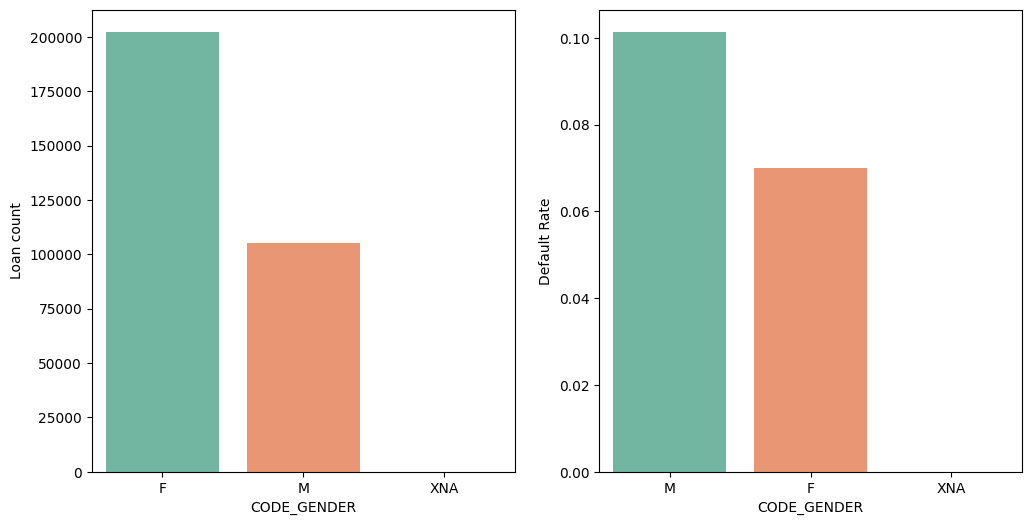

In [37]:
plot_stats('CODE_GENDER')

Женщин-клиентов почти вдвое больше мужчин, при этом мужчины показывают гораздо более высокий риск.

### Own Car or Realty

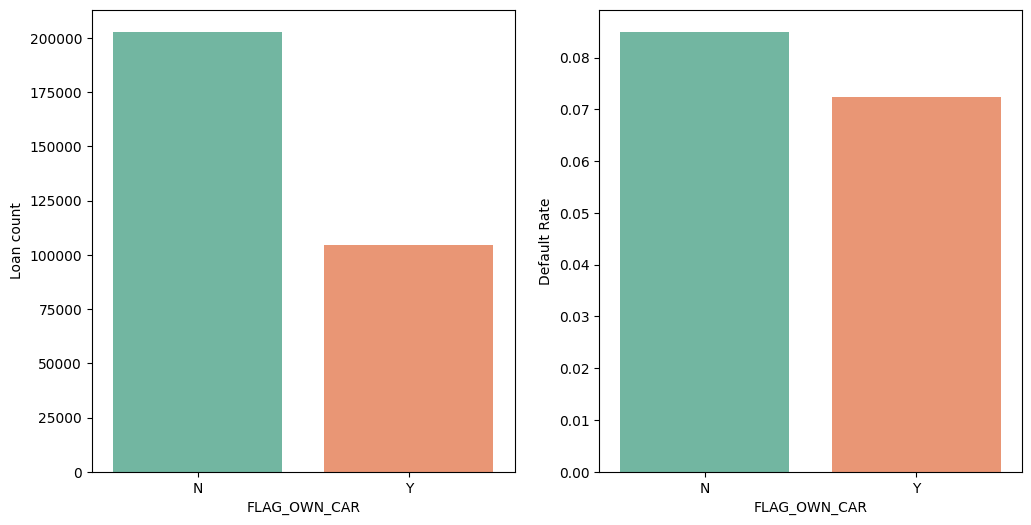

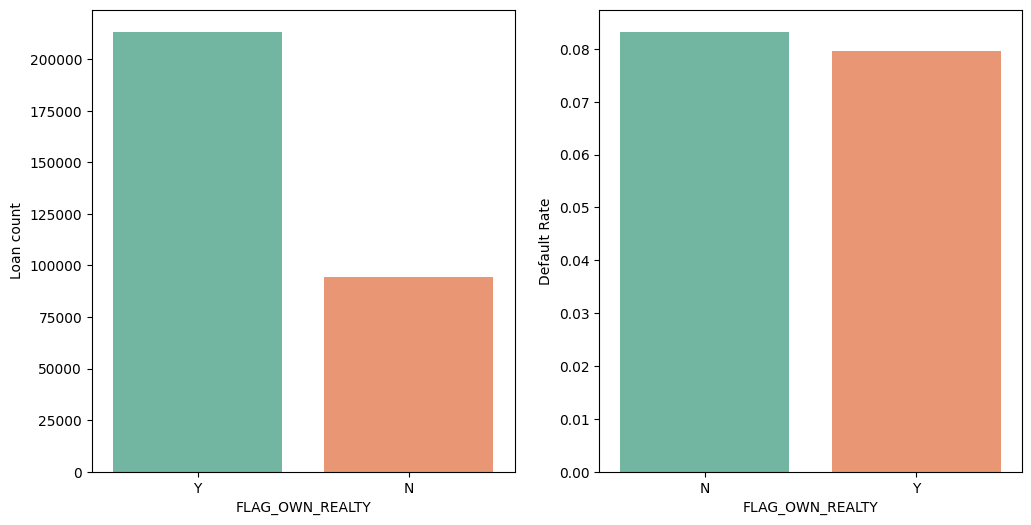

In [38]:
plot_stats('FLAG_OWN_CAR')
plot_stats('FLAG_OWN_REALTY')

Клиентов, не имеющих автомобиля, в два раза больше, чем тех, у кого он есть. Риск по ним практически одинаковый, клиенты с машиной платят чуть лучше.

По недвижимости обратная картина - клиентов без нее вдвое меньше. Риск по владельцам недвижимости также чуть меньше.

### Family status

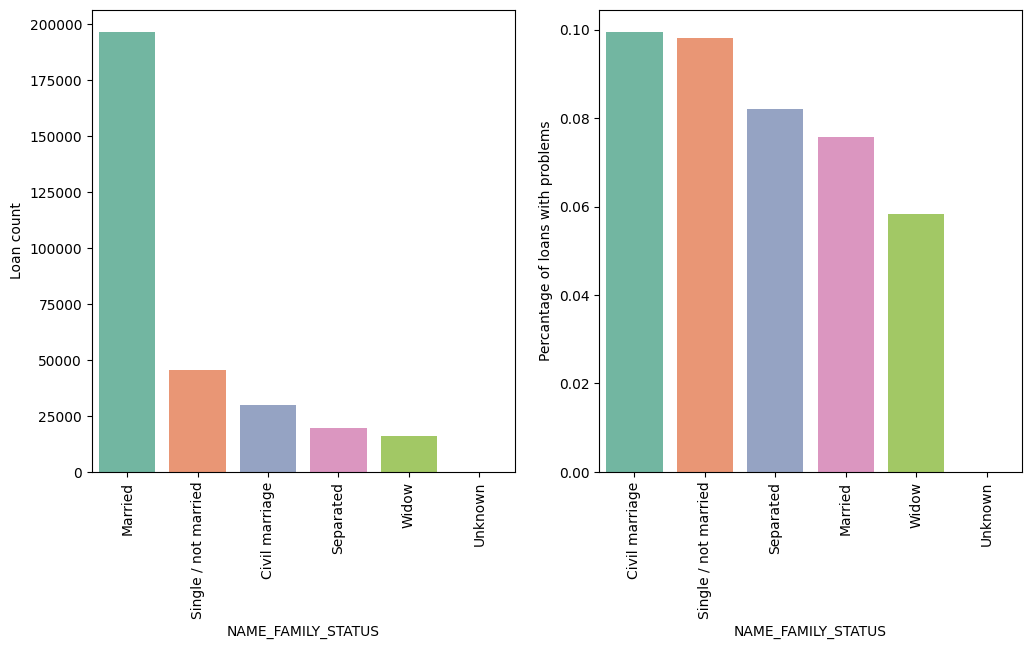

In [24]:
plot_stats('NAME_FAMILY_STATUS', 90)

В то время как большинство клиентов состоит в браке, ниаболее рискованы клиенты в гражданском браке и одинокие. Вдовцы показывают минимальный риск.

### Children count

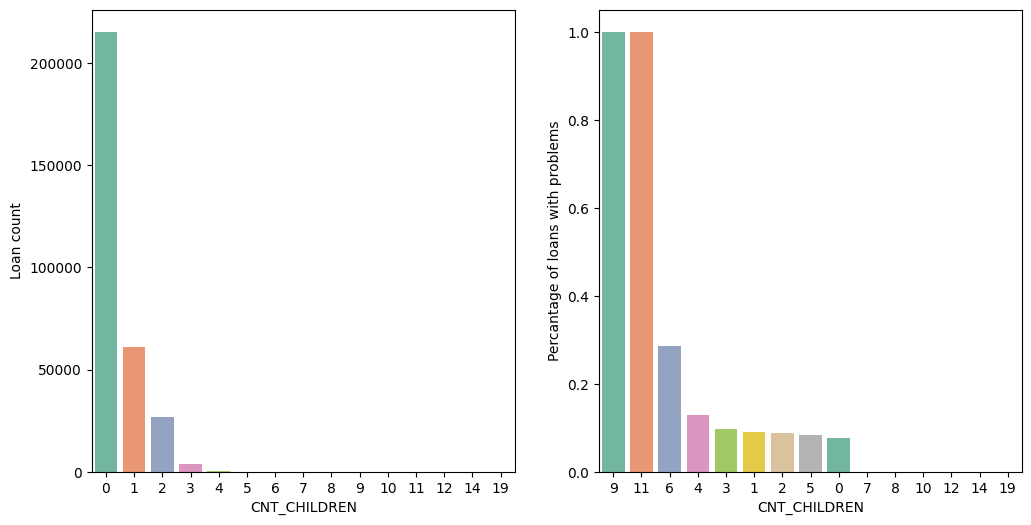

In [25]:
plot_stats('CNT_CHILDREN')

Большинство клиентов бездетны. При этом клиенты с 9 и 11 детьми показывют полный невозврат. Однако необходимо проверить, насколько эти данные статистически значимы:

In [26]:
application_train.CNT_CHILDREN.value_counts()

CNT_CHILDREN
0     215371
1      61119
2      26749
3       3717
4        429
5         84
6         21
7          7
14         3
8          2
9          2
12         2
10         2
19         2
11         1
Name: count, dtype: int64

Как показывает подсчет значений, эти данные не имеют веса - всего по 2 клиента обеих категорий (9 и 11 детей). Однако, все 4 вышли в дефолт, равно как и половина клиентов с 6 детьми.

Поэтому объединим всех клиентов, имеющих 4 и более детей в отдельную категорию 4+:

In [46]:
app_train[app_train['CNT_CHILDREN'] > 3]['CNT_CHILDREN'] = 4

### Family members count

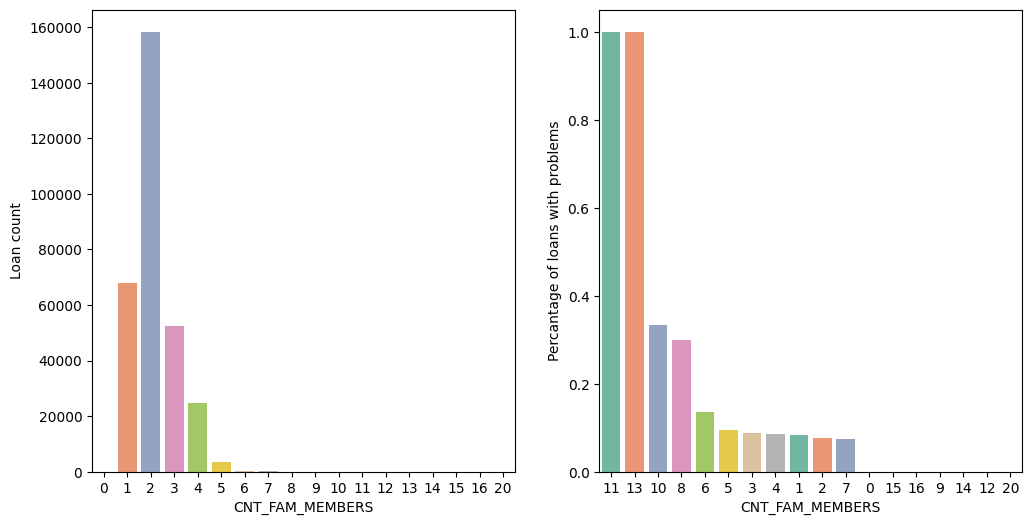

In [27]:
application_train.CNT_FAM_MEMBERS = application_train.CNT_FAM_MEMBERS.fillna(0).astype(int)
plot_stats('CNT_FAM_MEMBERS')

In [48]:
application_train.CNT_FAM_MEMBERS.value_counts()

CNT_FAM_MEMBERS
2.0     158357
1.0      67847
3.0      52601
4.0      24697
5.0       3478
6.0        408
7.0         81
8.0         20
9.0          6
10.0         3
14.0         2
12.0         2
20.0         2
16.0         2
13.0         1
15.0         1
11.0         1
Name: count, dtype: int64

Наблюдается та же закономерность — чем меньше членов в семье, тем выше вероятность возврата кредита. Для решения проблем с малочисленными классами, поступим также как и с CNT_CHILDREN

In [49]:
app_train[app_train['CNT_FAM_MEMBERS'] > 5]['CNT_FAM_MEMBERS'] = 6

### Income type (Пересмотреть)

In [53]:
app_train.NAME_INCOME_TYPE.value_counts()

NAME_INCOME_TYPE
Working                 158393
Commercial associate     71517
Pensioner                55341
State servant            21650
4                          555
Unemployed                  22
Student                     18
Businessman                 10
Maternity leave              5
Name: count, dtype: int64

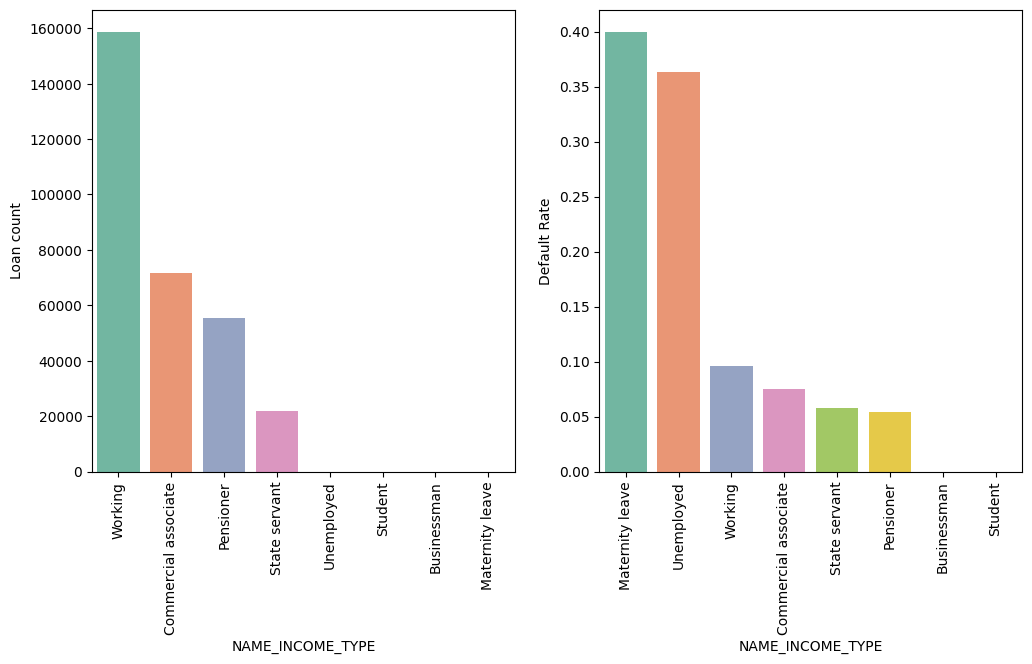

In [55]:
plot_stats('NAME_INCOME_TYPE', 90)

Матери-одиночки и безраьботные, скорее всего, отсекаются на этапе подачи заявки. Но стабильно показывают проблемы.

### Working sphere

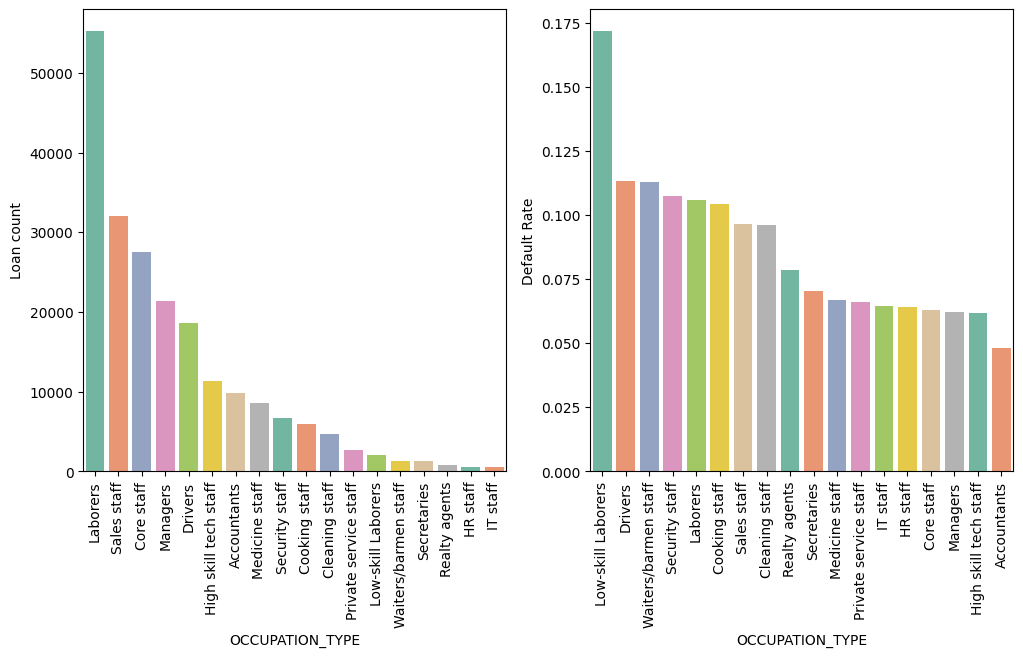

In [56]:
plot_stats('OCCUPATION_TYPE', 90)

In [57]:
application_train.OCCUPATION_TYPE.value_counts()

OCCUPATION_TYPE
Laborers                 55186
Sales staff              32102
Core staff               27570
Managers                 21371
Drivers                  18603
High skill tech staff    11380
Accountants               9813
Medicine staff            8537
Security staff            6721
Cooking staff             5946
Cleaning staff            4653
Private service staff     2652
Low-skill Laborers        2093
Waiters/barmen staff      1348
Secretaries               1305
Realty agents              751
HR staff                   563
IT staff                   526
Name: count, dtype: int64

Здесь вызывают интерес водители и сотрудники безопасности, которые довольно многочисленны и выходят на проблемы чаще других категорий.

### Education type

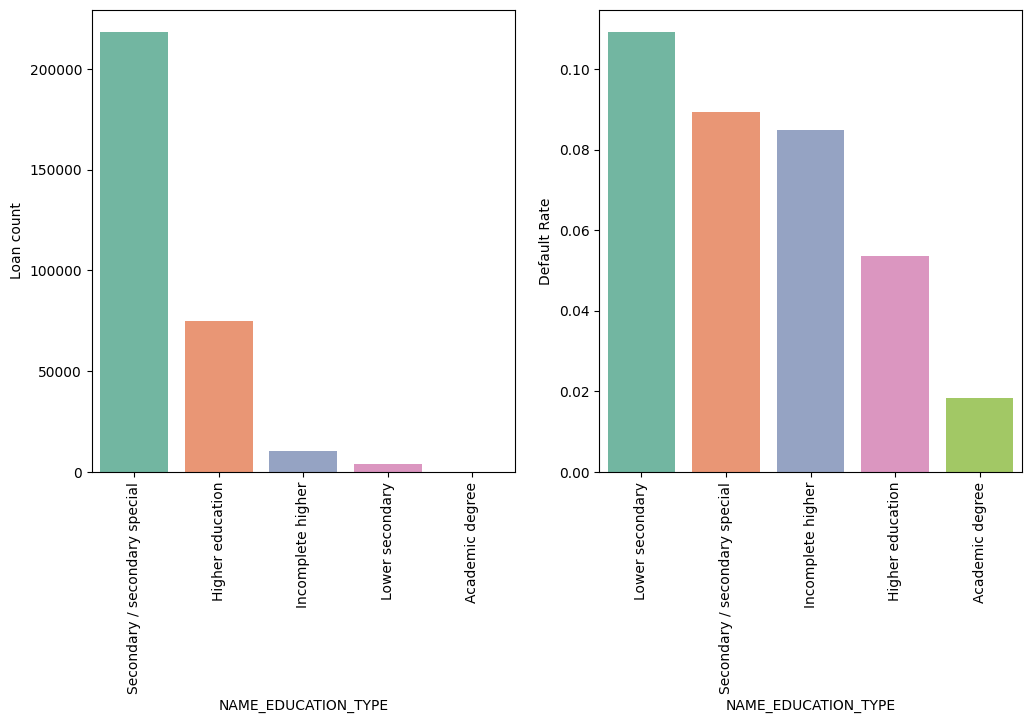

In [58]:
plot_stats('NAME_EDUCATION_TYPE', 90)

Чем выше образование, тем лучше возвратность, очевидно.

## Analysis of distributions

### Distribution by credit amount

Рассмотрим распределение сумм кредитов и влияние их на возвратность

<Axes: title={'center': 'Распределение AMT_CREDIT'}, xlabel='AMT_CREDIT', ylabel='Count'>

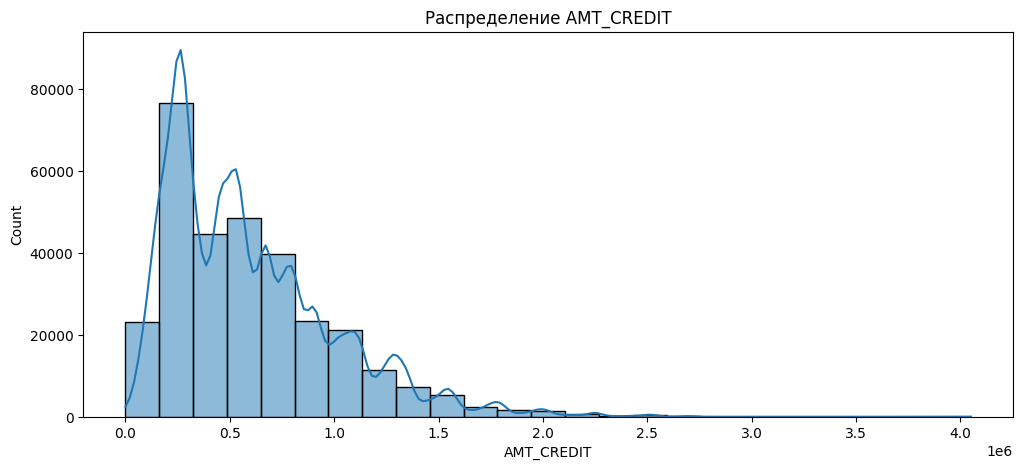

In [75]:
plt.figure(figsize=(12,5))
plt.title("Распределение AMT_CREDIT")
sns.histplot(app_train["AMT_CREDIT"], bins=25, kde=True)


Text(0.5, 1.0, 'Влияние суммы кредитования на плотность вероятности')

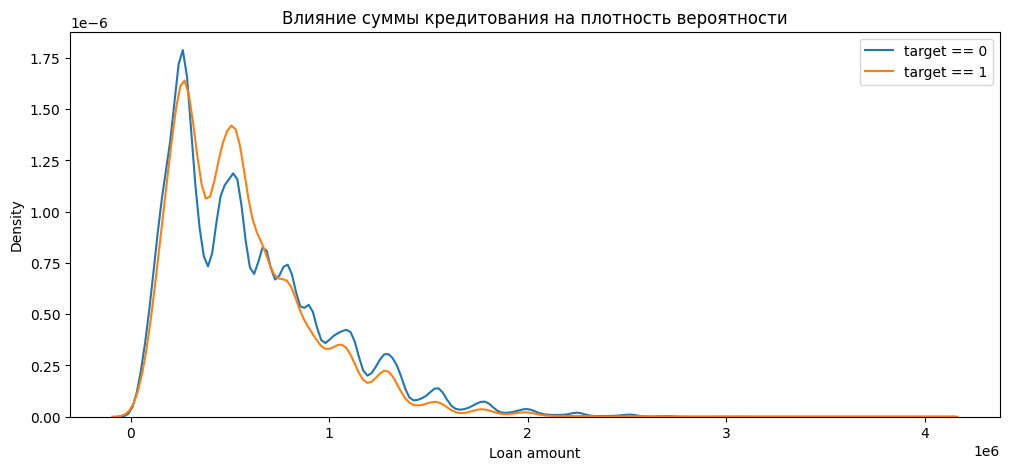

In [73]:
plt.figure(figsize=(12,5))

# KDE займов, выплаченных вовремя
sns.kdeplot(app_train.loc[app_train['TARGET'] == 0, 'AMT_CREDIT'], label = 'target == 0')

# KDE проблемных займов
sns.kdeplot(app_train.loc[app_train['TARGET'] == 1, 'AMT_CREDIT'], label = 'target == 1')

# Обозначения
plt.legend()
plt.xlabel('Loan amount')
plt.ylabel('Density')
plt.title('Влияние суммы кредитования на плотность вероятности')

Как показывает график плотности, крупные суммы возвращаются чаще

### Distribution by population density

REGION_POPULATION_RELATIVE – Normalized population of region where client lives (higher number means the client lives in more populated region)

<Axes: title={'center': 'Распределение REGION_POPULATION_RELATIVE'}, xlabel='REGION_POPULATION_RELATIVE', ylabel='Density'>

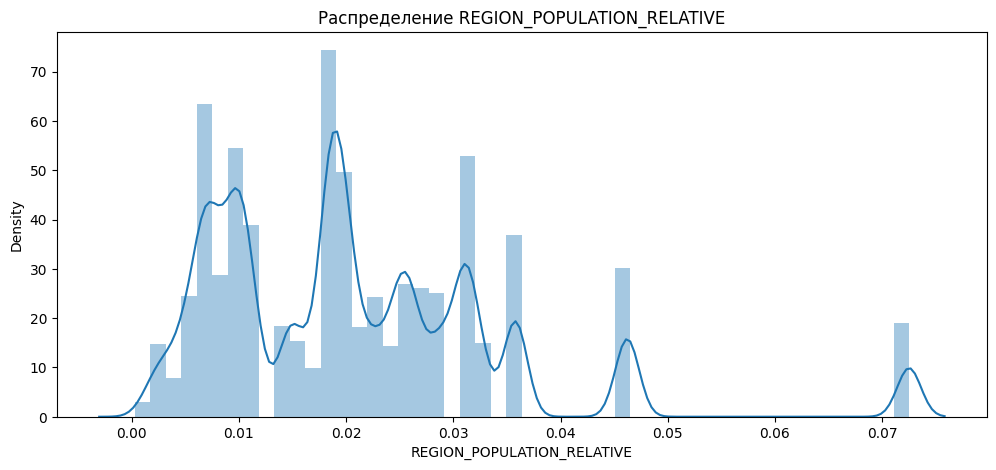

In [34]:
plt.figure(figsize=(12,5))
plt.title("Распределение REGION_POPULATION_RELATIVE")
sns.distplot(app_train["REGION_POPULATION_RELATIVE"])

Text(0.5, 1.0, 'Зависимость плотности вероятности от плотности населения')

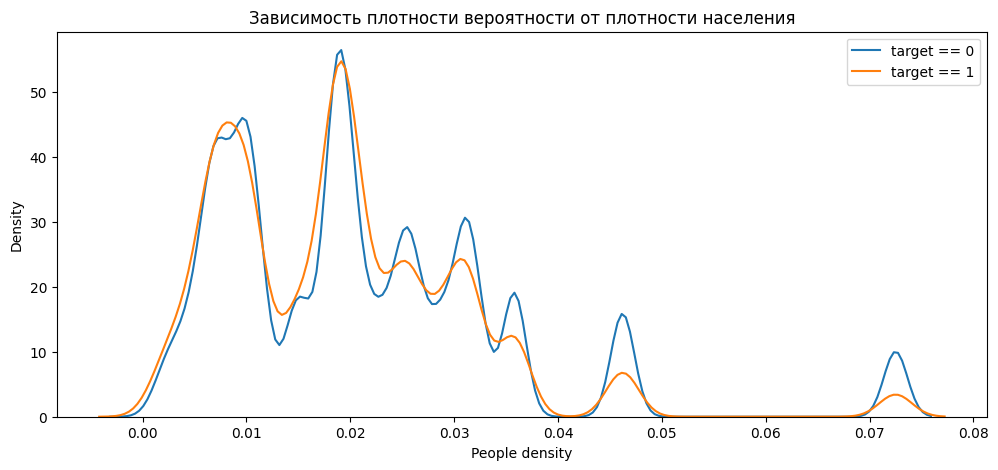

In [35]:
plt.figure(figsize=(12,5))

# KDE займов, выплаченных вовремя
sns.kdeplot(app_train.loc[app_train['TARGET'] == 0, 'REGION_POPULATION_RELATIVE'], label = 'target == 0')

# KDE проблемных займов
sns.kdeplot(app_train.loc[app_train['TARGET'] == 1, 'REGION_POPULATION_RELATIVE'], label = 'target == 1')

# Обозначения
plt.legend()
plt.xlabel('People density')
plt.ylabel('Density')
plt.title('Зависимость плотности вероятности от плотности населения')

Клиенты из более населенных регионов склонны лучше выплачивать кредит.

### Distribution by working experience

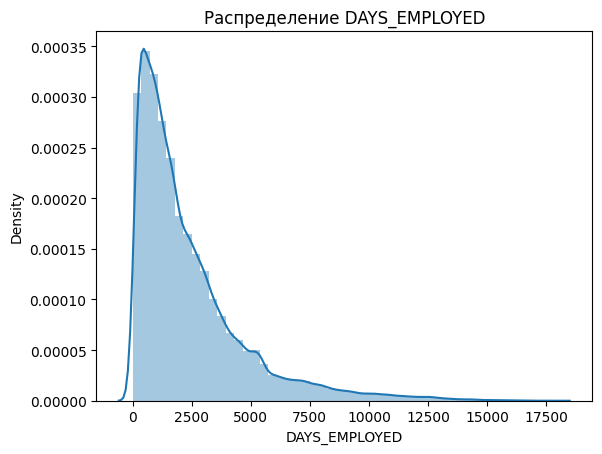

In [36]:
# число 365243 используется как заглушка для отсутствующего стажа
app_train['DAYS_EMPLOYED'].replace(365243, np.nan, inplace=True)
app_train['DAYS_EMPLOYED'] = abs(app_train['DAYS_EMPLOYED'])

plt.title('Распределение DAYS_EMPLOYED')
ax = sns.distplot(app_train["DAYS_EMPLOYED"])

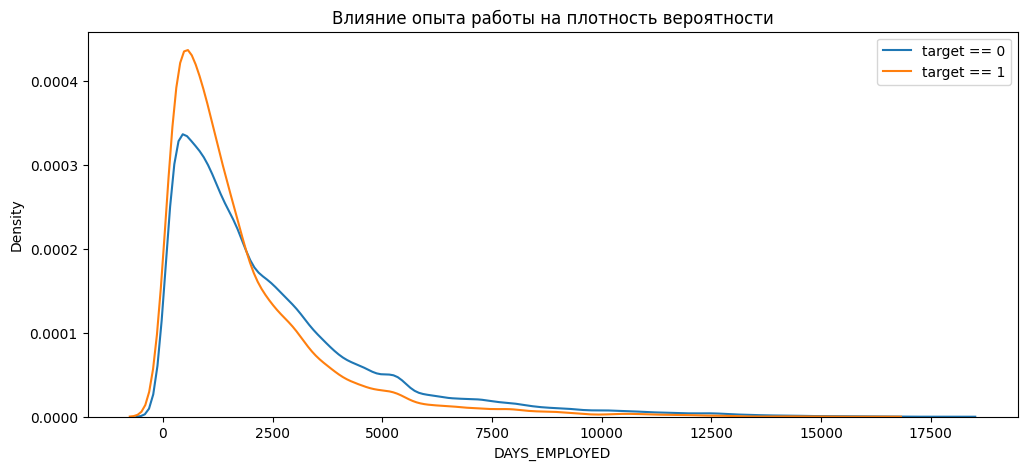

In [37]:
plt.figure(figsize=(12,5))

# KDE займов, выплаченных вовремя
sns.kdeplot(app_train.loc[app_train['TARGET'] == 0, 'DAYS_EMPLOYED'], label = 'target == 0')

# KDE проблемных займов
sns.kdeplot(app_train.loc[app_train['TARGET'] == 1, 'DAYS_EMPLOYED'], label = 'target == 1')

# Обозначения
plt.legend()
plt.xlabel('DAYS_EMPLOYED')
plt.ylabel('Density')
plt.title('Влияние опыта работы на плотность вероятности');


Теперь, удалив шумное значение '365243', можно заметить, что люди с бОльшим опытом работы на текущем месте менее проблемные заемщики.

# Data Cleaning and Feature Engineering

## Drop the outliers

In [38]:
upper = app_train['AMT_INCOME_TOTAL'].quantile(0.99)
app_train['AMT_INCOME_TOTAL'] = app_train['AMT_INCOME_TOTAL'].clip(upper=upper)

app_train = app_train[app_train['DAYS_EMPLOYED'] != app_train['DAYS_EMPLOYED'].max()]

## Deal with NaNs

In [39]:
# Если у человека нет машины, то, очевидно, у него нет и возраста автомобиля, поэтому просто заменим NaN на 0
app_train.OWN_CAR_AGE.fillna(0, inplace=True)
app_test.OWN_CAR_AGE.fillna(0, inplace=True)

In [40]:
# Сразу же удалим столбцы, в которых слишком большой процент пропусков
missing_pct = (app_train.isnull().sum() / len(app_train) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 1]

In [41]:
cols_to_drop = missing_pct.index[missing_pct > 57].tolist()
app_train = app_train.drop(columns=cols_to_drop)
app_test = app_test.drop(columns=cols_to_drop)

target = app_train['TARGET']
app_train.drop(columns=['TARGET'], inplace=True)

num_cols = app_train.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = app_train.select_dtypes(exclude=['float64', 'int64']).columns.tolist()

In [42]:
from sklearn.impute import SimpleImputer

imp_num = SimpleImputer(strategy='median')
app_train[num_cols] = imp_num.fit_transform(app_train[num_cols])
app_test[num_cols] = imp_num.transform(app_test[num_cols])

imp_cat = SimpleImputer(strategy='most_frequent')
app_train[cat_cols] = imp_cat.fit_transform(app_train[cat_cols].astype(str))
app_test[cat_cols] = imp_cat.transform(app_test[cat_cols].astype(str))

## Imputing NaN values

Далее мы воспользуемся KNNImputer, который по соседним числовым значениям восстановит нам все NaN-значения

Но перед этим необходимо отнормализовать значения, иначе фичи с большими числами (например, доход в миллионах) будут давить на «близость» соседей

In [43]:
# # Выберем только числовые признаки
# num_cols = app_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
# num_cols.remove('TARGET')
# # num_cols

In [44]:
# len(num_cols + ordinal_enc_cols)

In [45]:
# for df in [app_train, app_test]:
#     df[df.select_dtypes('float64').columns] = df.select_dtypes('float64').astype('float32')
#     df[df.select_dtypes('int64').columns]   = df.select_dtypes('int64').astype('int32')

# app_train.dtypes.value_counts()

In [46]:
# import pandas as pd
# from sklearn.feature_selection import mutual_info_classif
# from sklearn.impute import SimpleImputer

# def compute_mutual_info(df, target_col):
#     """
#     Считает mutual information для всех признаков (числовых и категориальных) относительно таргета.
#     df : pd.DataFrame
#     target_col : str
#     """
#     X = df.drop(columns=[target_col])
#     y = df[target_col]

#     # разделяем на числовые и категориальные
#     num_cols = X.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns
#     cat_cols = X.select_dtypes(exclude=['int64', 'float64', 'int32', 'float32']).columns

#     # Имьютация
#     X_num = pd.DataFrame(SimpleImputer(strategy='median').fit_transform(X[num_cols]),
#                          columns=num_cols, index=X.index)
#     X_cat = pd.DataFrame(SimpleImputer(strategy='most_frequent').fit_transform(X[cat_cols].astype(str)),
#                          columns=cat_cols, index=X.index)

#     # объединяем обратно
#     X_all = pd.concat([X_num, X_cat], axis=1)

#     # маска дискретных колонок
#     discrete_mask = [col in cat_cols for col in X_all.columns]

#     # mutual info
#     mi = mutual_info_classif(X_all, y, discrete_features=discrete_mask, random_state=42)

#     # результат
#     mi_series = pd.Series(mi, index=X_all.columns, name='mutual_info').sort_values(ascending=False)
#     return mi_series.to_frame()

In [47]:
# num_cols = app_train.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()

In [48]:
# num_cols.sort()
# # num_cols

In [49]:
# # target = app_train['TARGET']
# # app_train.drop(columns=['TARGET'], inplace=True)
# num_cols.remove('AGE_YEARS')

In [50]:
# X_num = pd.DataFrame(SimpleImputer(strategy='median').fit_transform(app_train[num_cols]),
#                          columns=num_cols, index=app_train.index)

In [51]:
# mi = mutual_info_classif(X_num, target, discrete_features=False, random_state=42)

In [52]:
# mi_series = pd.Series(mi, index=X_num.columns, name='mutual_info').sort_values(ascending=False)
# mi_series.to_frame()
# mi_series = mi_series[mi_series > 0.005]

# plt.figure(figsize=(5, 25))
# sns.barplot(x='mutual_info', y=mi_series.index, data=mi_series.reset_index())
# plt.title('Mutual Information with Target')
# plt.show()

In [53]:
# from sklearn.preprocessing import StandardScaler
# from sklearn.impute import KNNImputer

# # target = app_train['TARGET']
# # app_train.drop(columns=['TARGET'], inplace=True)

# KNN_scaler = StandardScaler()
# app_train_scaled = KNN_scaler.fit_transform(app_train[num_cols + ordinal_enc_cols])
# app_test_scaled = KNN_scaler.transform(app_test[num_cols + ordinal_enc_cols])

# KNN_imputer = KNNImputer(n_neighbors=3)
# app_train_imputed = KNN_imputer.fit_transform(app_train_scaled)
# app_test_imputed = KNN_imputer.transform(app_test_scaled)

## Column dtypes and categorical data handling

Далее посмотрим, распределение типов данных в датасете:

In [54]:
app_train.dtypes.value_counts()

float64    84
object     15
Name: count, dtype: int64

16 колонок в датасете имеют тип "объект" и нам нужно их заэнкодить. Осталось выбрать вариант энкодера

In [55]:
app_train.select_dtypes(include=[object]).apply(pd.Series.nunique).sort_values(ascending=False)

ORGANIZATION_TYPE             58
OCCUPATION_TYPE               19
NAME_TYPE_SUITE                8
NAME_INCOME_TYPE               8
WALLSMATERIAL_MODE             8
WEEKDAY_APPR_PROCESS_START     7
NAME_FAMILY_STATUS             6
NAME_HOUSING_TYPE              6
NAME_EDUCATION_TYPE            5
HOUSETYPE_MODE                 4
CODE_GENDER                    3
EMERGENCYSTATE_MODE            3
NAME_CONTRACT_TYPE             2
FLAG_OWN_CAR                   2
FLAG_OWN_REALTY                2
dtype: int64

In [56]:
app_train.NAME_EDUCATION_TYPE.unique()

array(['Secondary / secondary special', 'Higher education',
       'Incomplete higher', 'Lower secondary', 'Academic degree'],
      dtype=object)

Как мы видим, можно отранжировать типы образования (например, по возрастанию) и каждому типу присвоить свое число.

Теперь при помощи SimpleImputer заменим все NaN-значения в категориальных столбцах на самый частый класс

In [57]:
# Выделим все колонки с категориальными признаками
object_cols = app_train.select_dtypes(include=['object']).columns.tolist()

In [58]:
from sklearn.impute import SimpleImputer

# Cначала избавляемся от NaN, чтобы они попали в список категорий
imp_mode = SimpleImputer(strategy='most_frequent')
app_train[object_cols] = imp_mode.fit_transform(app_train[object_cols])
app_test[object_cols] = imp_mode.transform(app_test[object_cols])

Далее займемся энкодерами

Фичи, в которых всего два уникальных значения будем кодировать при помощи OrdinalEncoder:

In [59]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_enc_cols = [
    'NAME_EDUCATION_TYPE',
    'CODE_GENDER',
    'FLAG_OWN_CAR',
    'NAME_CONTRACT_TYPE',
    'FLAG_OWN_REALTY',
    'EMERGENCYSTATE_MODE'
]

# Формируем список категорий для 'NAME_EDUCATION_TYPE'
categories = [
    [
        'Lower secondary',
        'Secondary / secondary special',
        'Incomplete higher',
        'Higher education',
        'Academic degree'
    ]
]

# Для остальных колонок получаем уникальные значения в порядке появления
for col in ordinal_enc_cols[1:]:
    cats = list(app_train[col].unique())
    categories.append(cats)

ordinal_enc = OrdinalEncoder(
    categories=categories,
    handle_unknown='use_encoded_value',
    unknown_value=-1,
    dtype=int
)

app_train[ordinal_enc_cols] = ordinal_enc.fit_transform(app_train[ordinal_enc_cols])
app_test[ordinal_enc_cols] = ordinal_enc.fit_transform(app_test[ordinal_enc_cols])

А всё остальное - OneHotEncoderом

In [60]:
one_hot_enc_cols = [
    'ORGANIZATION_TYPE',
    'OCCUPATION_TYPE',
    'NAME_INCOME_TYPE',
    'NAME_TYPE_SUITE',
    'WALLSMATERIAL_MODE',
    'WEEKDAY_APPR_PROCESS_START',
    'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE',
    'HOUSETYPE_MODE'
]

app_train = pd.get_dummies(app_train, columns=one_hot_enc_cols)
app_test = pd.get_dummies(app_test, columns=one_hot_enc_cols)

In [61]:
print('После OneHot:')
print('Формат тренировочной выборки: ', app_train.shape)
print('Формат тестовой выборки: ', app_test.shape)

После OneHot:
Формат тренировочной выборки:  (307510, 214)
Формат тестовой выборки:  (48744, 212)


Теперь у нас появились столбцы, которых нет в обеих выборках. Нам поможет метод align()

In [62]:
# Выравнивание - сохранятся только столбцы. имеющиеся в обоих датафреймах
app_train, app_test = app_train.align(app_test, join = 'inner', axis = 1)

print('После align():')
print('Формат тренировочной выборки: ', app_train.shape)
print('Формат тестовой выборки: ', app_test.shape)

# Add target back into the data
app_train['TARGET'] = target

После align():
Формат тренировочной выборки:  (307510, 212)
Формат тестовой выборки:  (48744, 212)


## Polinomial features

Выберем только важные признаки и лишь из них сделаем полиномы, во избежание переобучения:

In [63]:
# Cоздадим новый датафрейм для полиномиальных признаков
poly_features = app_train[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'AGE_YEARS']]
poly_features_test = app_test[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'AGE_YEARS']]

In [64]:
from sklearn.preprocessing import PolynomialFeatures

# Создадим полиномиальный объект степени 3
poly_transformer = PolynomialFeatures(degree = 3)

# Тренировка полиномиальных признаков
poly_transformer.fit(poly_features)

# Трансформация признаков
poly_features = poly_transformer.transform(poly_features)
poly_features_test = poly_transformer.transform(poly_features_test)
print('Формат полиномиальных признаков: ', poly_features.shape)

Формат полиномиальных признаков:  (307510, 35)


Присвоим признакам имена при помощи метода get_feature_names:


In [65]:
poly_transformer.get_feature_names_out(input_features = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'AGE_YEARS'])[:15]

array(['1', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'AGE_YEARS',
       'EXT_SOURCE_1^2', 'EXT_SOURCE_1 EXT_SOURCE_2',
       'EXT_SOURCE_1 EXT_SOURCE_3', 'EXT_SOURCE_1 AGE_YEARS',
       'EXT_SOURCE_2^2', 'EXT_SOURCE_2 EXT_SOURCE_3',
       'EXT_SOURCE_2 AGE_YEARS', 'EXT_SOURCE_3^2',
       'EXT_SOURCE_3 AGE_YEARS', 'AGE_YEARS^2'], dtype=object)

Итого 35 полиномиальных и производных признаков. Проверих их корреляцию с таргетом.

In [66]:
# Датафрейм для новых фич
poly_features = pd.DataFrame(poly_features,
                             columns = poly_transformer.get_feature_names_out(['EXT_SOURCE_1', 'EXT_SOURCE_2',
                                                                           'EXT_SOURCE_3', 'AGE_YEARS']))
poly_features_test = pd.DataFrame(poly_features_test,
                                  columns = poly_transformer.get_feature_names_out(['EXT_SOURCE_1', 'EXT_SOURCE_2',
                                                                                'EXT_SOURCE_3', 'AGE_YEARS']))

# Добавим таргет
poly_features_with_TARGET = poly_features.copy()
poly_features_with_TARGET['TARGET'] = target

# Рассчитаем корреляцию
poly_corrs = poly_features_with_TARGET.corr()['TARGET'].sort_values()

# Отобразим признаки с наивысшей корреляцией
print(poly_corrs.head(10))
print(poly_corrs.tail(5))

EXT_SOURCE_2 EXT_SOURCE_3                -0.178014
EXT_SOURCE_1 EXT_SOURCE_2 EXT_SOURCE_3   -0.173867
EXT_SOURCE_2 EXT_SOURCE_3 AGE_YEARS      -0.166366
EXT_SOURCE_2^2 EXT_SOURCE_3              -0.161767
EXT_SOURCE_2 EXT_SOURCE_3^2              -0.158300
EXT_SOURCE_1 EXT_SOURCE_2                -0.152347
EXT_SOURCE_1 EXT_SOURCE_3                -0.150282
EXT_SOURCE_2                             -0.146858
EXT_SOURCE_2 AGE_YEARS                   -0.143552
EXT_SOURCE_1 EXT_SOURCE_2^2              -0.143275
Name: TARGET, dtype: float64
AGE_YEARS     -0.071492
AGE_YEARS^2   -0.069996
AGE_YEARS^3   -0.067779
TARGET         1.000000
1                   NaN
Name: TARGET, dtype: float64


Итак, некоторые признаки показывают более высокую корреляцию, чем исходные. Есть смысл попробовать обучение с ними и без них. Для этого присоединим полиномиальные признаки к основному DF.

In [67]:
# Объединим тренировочные датафреймы
poly_features['SK_ID_CURR'] = app_train['SK_ID_CURR']
app_train_poly = app_train.merge(poly_features, on = 'SK_ID_CURR', how = 'left')

# Объединим тестовые датафреймы
poly_features_test['SK_ID_CURR'] = app_test['SK_ID_CURR']
app_test_poly = app_test.merge(poly_features_test, on = 'SK_ID_CURR', how = 'left')

# Посмотрим формат
print('Тренировочная выборка с полиномиальными признаками: ', app_train_poly.shape)
print('Тестовая выборка с полиномиальными признаками: ', app_test_poly.shape)

Тренировочная выборка с полиномиальными признаками:  (307510, 248)
Тестовая выборка с полиномиальными признаками:  (48744, 247)


# Model Training

## Model evaluation functions

Создадим функцию для подбора гиперпараметров при помощи Optuna

In [68]:
import optuna
from sklearn.model_selection import cross_val_score, StratifiedKFold

def optuna_tune(model_class, param_space_func, X, y, n_trials=60, cv_num=5):

    def objective(trial):
        params = param_space_func(trial)
        model = model_class(**params)
        cv= StratifiedKFold(n_splits=cv_num, shuffle=True, random_state=42)

        # Get AUC_score from cross validation
        score = cross_val_score(
            model, X, y,
            cv=cv,
            scoring='roc_auc',
            n_jobs=-1
        ).mean()
        return score

    study = optuna.create_study(direction='maximize', storage="sqlite:///optuna_logs.db", study_name=model_class.__name__, load_if_exists=True)
    study.optimize(objective, n_trials=n_trials)
    print("Лучшие параметры:", study.best_params)
    print("Лучший AUC:", study.best_value)

    # Fit the best model with the entire dataset for easy production use
    best_model = model_class(**study.best_params)
    best_model.fit(X, y)

    return study, best_model

## 1) Get Baseline - Logistic Regression

Для применения логистической регрессии нам нужно взять таблицы с закодированными категориальными признаками, заполнить недостающие данные и нормализовать их (привести к значениям от 0 до 1).

Для удобства применим class Pipeline

In [69]:
from sklearn.model_selection import train_test_split

app_train.drop(columns=['TARGET'], inplace=True)

X_train, X_val, y_train, y_val = train_test_split(app_train, target, test_size=0.2, random_state=42, stratify=target)
X_kaggle = app_test

Создадим функцию для построения кривой ROC и создания csv-файла, который позже пойдет в Kaggle для сабмита

In [70]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

def get_score(pipeline, csv_name):

    y_kaggle_proba = pipeline.predict_proba(X_kaggle)[:, 1]
    y_val_proba = pipeline.predict_proba(X_val)[:, 1]

    # Make submission-file for Kaggle
    submission = pd.DataFrame({'SK_ID_CURR': X_kaggle['SK_ID_CURR'], 'TARGET': y_kaggle_proba})
    submission['SK_ID_CURR'] = submission['SK_ID_CURR'].astype(int)
    submission.to_csv(csv_name, index=False)

    # Plotting ROC-curve
    fpr, tpr, _ = roc_curve(y_val,  y_val_proba)
    auc = roc_auc_score(y_val, y_val_proba)

    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}', color='blue')
    plt.plot([0, 1], [0, 1], linestyle='--', color='green') # lame-classifier
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

Epoch 1, change: 1
Epoch 2, change: 0.32164051
Epoch 3, change: 0.19158392
Epoch 4, change: 0.13442542
Epoch 5, change: 0.10980426
Epoch 6, change: 0.089811341
Epoch 7, change: 0.075704197
Epoch 8, change: 0.065366609
Epoch 9, change: 0.056219609
Epoch 10, change: 0.04929357
Epoch 11, change: 0.043336133
Epoch 12, change: 0.038352562
Epoch 13, change: 0.034051244
Epoch 14, change: 0.030435624
Epoch 15, change: 0.027138746
Epoch 16, change: 0.024349358
Epoch 17, change: 0.021894418
Epoch 18, change: 0.019804668
Epoch 19, change: 0.017843393
Epoch 20, change: 0.01618497
Epoch 21, change: 0.014650759
Epoch 22, change: 0.013361794
Epoch 23, change: 0.01214874
Epoch 24, change: 0.011078099
Epoch 25, change: 0.01014379
Epoch 26, change: 0.0092635961
Epoch 27, change: 0.0084743311
Epoch 28, change: 0.0077766155
Epoch 29, change: 0.0071393874
max_iter reached after 14 secondsEpoch 30, change: 0.0065448885



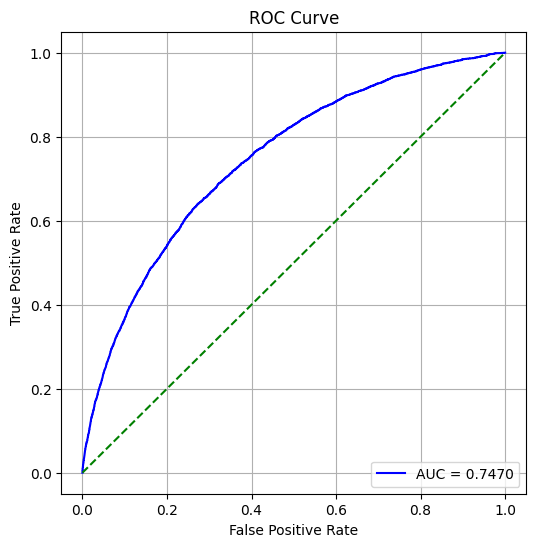

In [71]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Pipeline: scaler + logistic regression
pipeline_logreg = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(
                                  penalty="elasticnet",
                                  solver="saga",
                                  l1_ratio=0.9,
                                  max_iter=30,
                                  verbose=1,
                                  random_state=42
                                  ))
])

# Learning....
pipeline_logreg.fit(X_train, y_train)

get_score(pipeline_logreg, 'Kaggle Submissions/submission_logreg.csv')

Выполнение кода заняло 16 секунд

Kaggle Score = 0.69638

## 2) Decision Trees

Проделаем то же самое с простейшим "деревянным" алгоритмом

[I 2025-10-04 21:46:04,724] Using an existing study with name 'DecisionTreeClassifier' instead of creating a new one.
[I 2025-10-04 21:46:20,436] Trial 102 finished with value: 0.7134906159270686 and parameters: {'criterion': 'log_loss', 'max_depth': 8, 'min_samples_split': 15, 'min_samples_leaf': 4, 'max_features': None}. Best is trial 83 with value: 0.7153202452364742.


Лучшие параметры: {'criterion': 'log_loss', 'max_depth': 7, 'min_samples_split': 16, 'min_samples_leaf': 4, 'max_features': None}
Лучший AUC: 0.7153202452364742


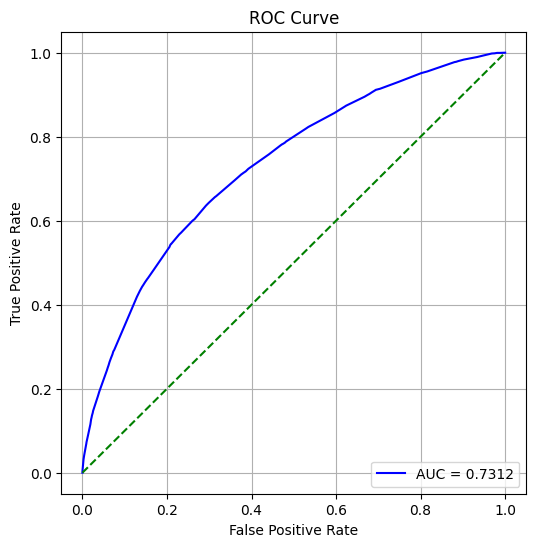

In [72]:
from sklearn.tree import DecisionTreeClassifier

def decision_tree_param_space(trial):
    return {
        "criterion": trial.suggest_categorical("criterion", ["gini", "entropy", "log_loss"]),
        "max_depth": trial.suggest_int("max_depth", 3, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None])
    }

# Optuna tuning
study, best_decision_tree= optuna_tune(DecisionTreeClassifier, decision_tree_param_space, app_train, target, n_trials=1, cv_num=5)

# Get AUC and Kaggle-score
get_score(best_decision_tree, 'submission_decision_tree.csv')


Подбор гиперпараметров занял 3 минуты

Kaggle Score = 0.70369

## 3) Random Forest

[I 2025-10-04 22:08:07,697] Using an existing study with name 'RandomForestClassifier' instead of creating a new one.
[I 2025-10-04 22:09:20,335] Trial 6 finished with value: 0.7185992716425431 and parameters: {'n_estimators': 655, 'max_depth': 5, 'min_samples_split': 17, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 0 with value: 0.7383588054279028.


Лучшие параметры: {'n_estimators': 532, 'max_depth': 23, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': True}
Лучший AUC: 0.7383588054279028


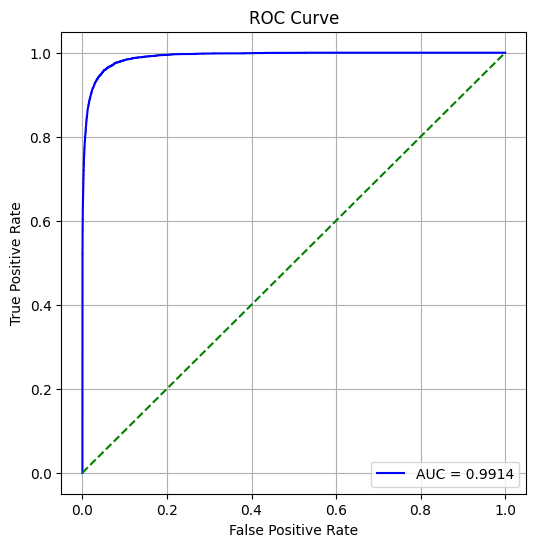

In [77]:
from sklearn.ensemble import RandomForestClassifier

def random_forest_param_space(trial):
    return {
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),
        "max_depth": trial.suggest_int("max_depth", 5, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False])
    }

# Optuna tuning
study, best_random_forest = optuna_tune(RandomForestClassifier, random_forest_param_space, app_train, target, n_trials=1, cv_num=2)

# Get AUC and Kaggle-score
get_score(best_random_forest, 'submission_random_forest.csv')

Kaggle-score = 0,71350

## 4) CatBoost

В дальнейшем можно попробовать применить catboost на данных без предварительного энкодинга, ибо его алгоритмы должны справиться с этим лучше

[I 2025-10-04 22:06:34,046] Using an existing study with name 'CatBoostClassifier' instead of creating a new one.
[I 2025-10-04 22:07:12,960] Trial 8 finished with value: 0.7567704390431982 and parameters: {'iterations': 317, 'depth': 7, 'learning_rate': 0.18782947430373903, 'l2_leaf_reg': 9.895961914634738, 'border_count': 173, 'random_strength': 0.10433701719180166}. Best is trial 3 with value: 0.7589806146251737.


Лучшие параметры: {'iterations': 482, 'depth': 7, 'learning_rate': 0.07165084122688875, 'l2_leaf_reg': 4.442644523588386, 'border_count': 93, 'random_strength': 0.4577034199485801}
Лучший AUC: 0.7589806146251737
0:	learn: 0.6163118	total: 92ms	remaining: 44.3s
1:	learn: 0.5521999	total: 123ms	remaining: 29.4s
2:	learn: 0.5032152	total: 153ms	remaining: 24.4s
3:	learn: 0.4613180	total: 181ms	remaining: 21.6s
4:	learn: 0.4264850	total: 210ms	remaining: 20.1s
5:	learn: 0.3991043	total: 240ms	remaining: 19s
6:	learn: 0.3755896	total: 270ms	remaining: 18.3s
7:	learn: 0.3562214	total: 300ms	remaining: 17.8s
8:	learn: 0.3412080	total: 331ms	remaining: 17.4s
9:	learn: 0.3269876	total: 367ms	remaining: 17.3s
10:	learn: 0.3153388	total: 398ms	remaining: 17.1s
11:	learn: 0.3055102	total: 430ms	remaining: 16.8s
12:	learn: 0.2979663	total: 464ms	remaining: 16.7s
13:	learn: 0.2915372	total: 502ms	remaining: 16.8s
14:	learn: 0.2855442	total: 536ms	remaining: 16.7s
15:	learn: 0.2805809	total: 567ms	re

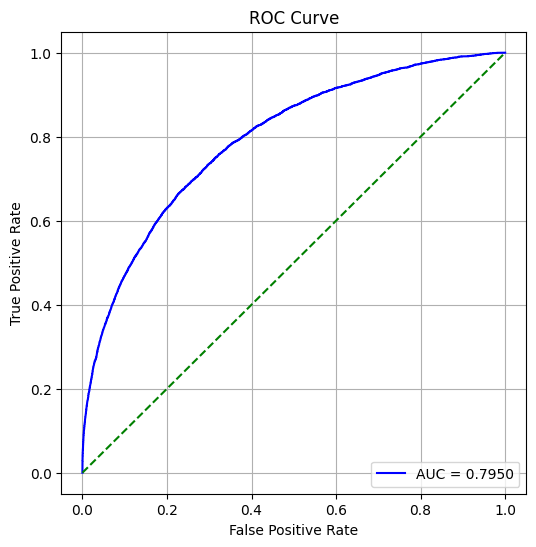

In [75]:
from catboost import CatBoostClassifier

def catboost_param_space(trial):
    return {
        "iterations": trial.suggest_int("iterations", 300, 500),
        "depth": trial.suggest_int("depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
        "border_count": trial.suggest_int("border_count", 32, 255),
        "random_strength": trial.suggest_float("random_strength", 0, 1),
        "bootstrap_type": "Bernoulli",
        "verbose": 0,
        "random_state": 42
    }


# Optuna tuning
study, best_catboost = optuna_tune(CatBoostClassifier, catboost_param_space, app_train, target, n_trials=1, cv_num=5)

# Get AUC and Kaggle-score
get_score(best_catboost, 'submission_catboost.csv')

Kaggle-score = 0,73924

# Export to the PROD

Из всех моделей осталось выбрать наилучшую по Kaggle-score и дальше через FastAPI & Streamlit UI сделать полноценное приложение.

In [78]:
import joblib

# Save the production model
joblib.dump(pipeline_logreg, "models/pipeline_logreg.joblib")
joblib.dump(best_decision_tree, "models/best_decision_tree.joblib")
joblib.dump(best_random_forest, "models/best_random_forest.joblib")
joblib.dump(best_catboost, "models/best_catboost.joblib")

['models/best_catboost.joblib']